## Chargement des bibliothèques et des données
Chargement des bibliothèques nécessaires pour l'entraînement des modèles 
et des données prétraitées générées dans le notebook 02.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report


X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train_binary = pd.read_csv('../data/processed/y_train_binary.csv').squeeze()
y_test_binary = pd.read_csv('../data/processed/y_test_binary.csv').squeeze()
y_train_multi = pd.read_csv('../data/processed/y_train_multi.csv').squeeze()
y_test_multi = pd.read_csv('../data/processed/y_test_multi.csv').squeeze()

## Définition des modèles
Définition des 7 modèles de machine learning utilisés pour la classification binaire avec leurs hyperparamètres. Le choix de ces modèles est basé sur l'étude de la littérature réalisée dans ce travail. 

In [3]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=50,
        min_samples_leaf=4,
        random_state=42),
    
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200,
        random_state=42),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=50,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=42),
    
    'DNN': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=300,
        random_state=42),
    
    'XGBoost': XGBClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42,
        eval_metric='logloss'),
    
    'CatBoost': CatBoostClassifier(
        iterations=200,
        random_state=42,
        verbose=0)
}

## Entraînement et évaluation - Classification Binaire
Entraînement de chaque modèle sur les données d'entraînement et évaluation 
sur les données de test. Quatre métriques sont calculées pour chaque modèle : 
Accuracy, F1-score, Precision et Recall.

In [ ]:

results_binary = {}

for name, model in models.items():
    print(f'Entraînement de {name}...')
    model.fit(X_train, y_train_binary)
    y_pred = model.predict(X_test)
    
    results_binary[name] = {
        'accuracy'  : accuracy_score(y_test_binary, y_pred),
        'f1'        : f1_score(y_test_binary, y_pred),
        'precision' : precision_score(y_test_binary, y_pred),
        'recall'    : recall_score(y_test_binary, y_pred)
    }
    
    print(f'  Accuracy  : {results_binary[name]["accuracy"]:.4f}')
    print(f'  F1-score  : {results_binary[name]["f1"]:.4f}')
    print(f'  Precision : {results_binary[name]["precision"]:.4f}')
    print(f'  Recall    : {results_binary[name]["recall"]:.4f}')
    print()

print('Entraînement binaire terminé')

=== Classification Binaire ===

Entraînement de Logistic Regression...
  Accuracy  : 0.7164
  F1-score  : 0.4951
  Precision : 0.8920
  Recall    : 0.3426

Entraînement de Decision Tree...
  Accuracy  : 0.8649
  F1-score  : 0.8284
  Precision : 0.8546
  Recall    : 0.8037

Entraînement de AdaBoost...
  Accuracy  : 0.7579
  F1-score  : 0.6101
  Precision : 0.8802
  Recall    : 0.4669

Entraînement de Random Forest...
  Accuracy  : 0.9007
  F1-score  : 0.8660
  Precision : 0.9575
  Recall    : 0.7904

Entraînement de DNN...
  Accuracy  : 0.8272
  F1-score  : 0.7347
  Precision : 0.9741
  Recall    : 0.5898

Entraînement de XGBoost...
  Accuracy  : 0.8377
  F1-score  : 0.7537
  Precision : 0.9808
  Recall    : 0.6120

Entraînement de CatBoost...
  Accuracy  : 0.8294
  F1-score  : 0.7400
  Precision : 0.9701
  Recall    : 0.5981

Entraînement binaire terminé


## Sauvegarde des modèles
Sauvegarde de chaque modèle entraîné au format pickle dans le dossier "models/"pour une réutilisation dans le notebook XAI sans avoir à réentraîner.

In [ ]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

for name, model in models.items():
    filename = name.lower().replace(' ', '_')
    with open(f'../models/{filename}_binary.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f'Modèle sauvegardé : {filename}_binary.pkl')

Modèle sauvegardé : logistic_regression_binary.pkl
Modèle sauvegardé : decision_tree_binary.pkl
Modèle sauvegardé : adaboost_binary.pkl
Modèle sauvegardé : random_forest_binary.pkl
Modèle sauvegardé : dnn_binary.pkl
Modèle sauvegardé : xgboost_binary.pkl
Modèle sauvegardé : catboost_binary.pkl
Sauvegarde terminée


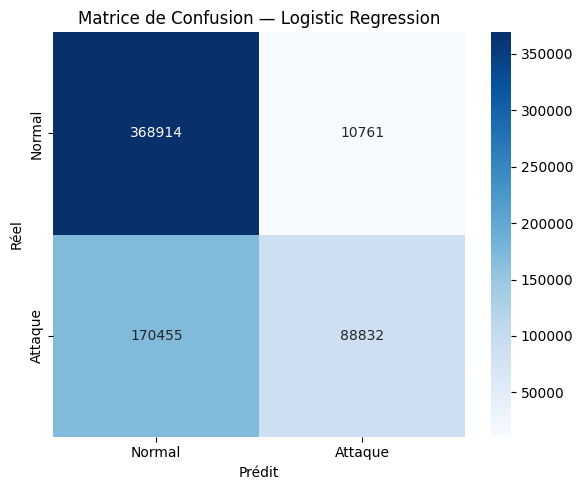

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80    379675
     Attaque       0.89      0.34      0.50    259287

    accuracy                           0.72    638962
   macro avg       0.79      0.66      0.65    638962
weighted avg       0.77      0.72      0.68    638962




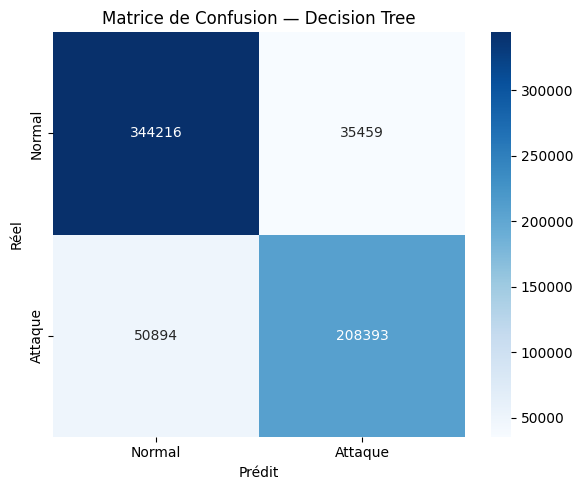

=== Decision Tree ===
              precision    recall  f1-score   support

      Normal       0.87      0.91      0.89    379675
     Attaque       0.85      0.80      0.83    259287

    accuracy                           0.86    638962
   macro avg       0.86      0.86      0.86    638962
weighted avg       0.86      0.86      0.86    638962




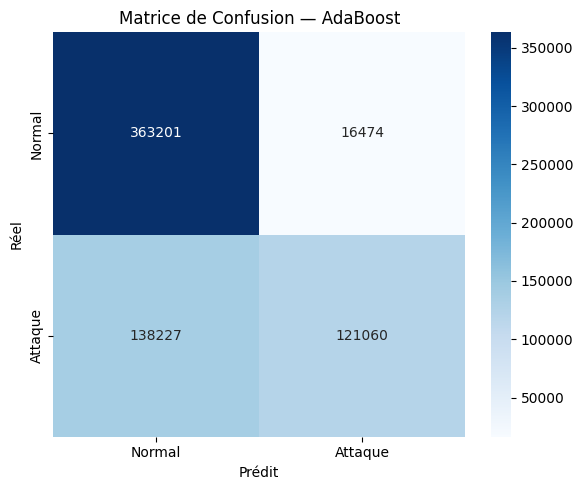

=== AdaBoost ===
              precision    recall  f1-score   support

      Normal       0.72      0.96      0.82    379675
     Attaque       0.88      0.47      0.61    259287

    accuracy                           0.76    638962
   macro avg       0.80      0.71      0.72    638962
weighted avg       0.79      0.76      0.74    638962




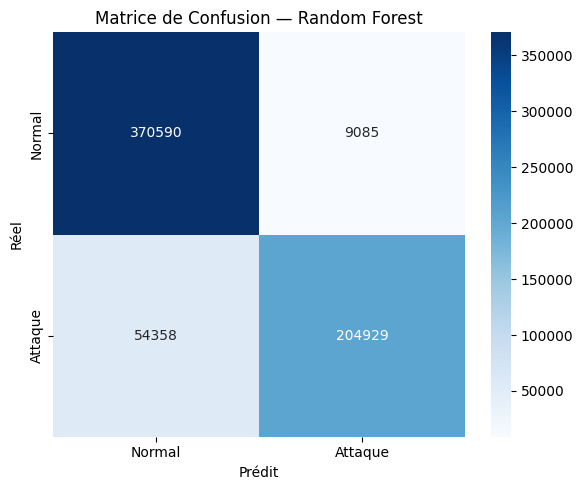

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.87      0.98      0.92    379675
     Attaque       0.96      0.79      0.87    259287

    accuracy                           0.90    638962
   macro avg       0.91      0.88      0.89    638962
weighted avg       0.91      0.90      0.90    638962




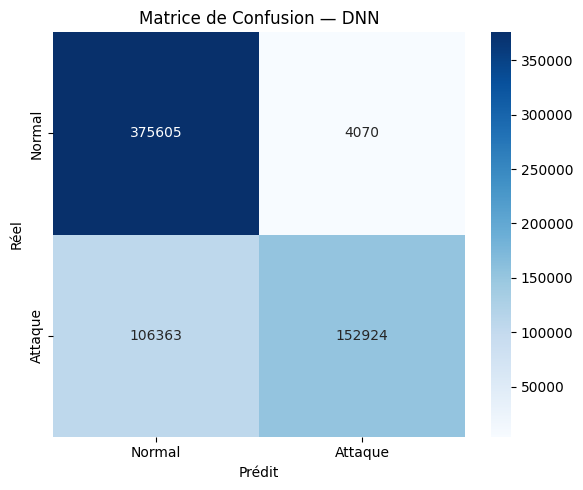

=== DNN ===
              precision    recall  f1-score   support

      Normal       0.78      0.99      0.87    379675
     Attaque       0.97      0.59      0.73    259287

    accuracy                           0.83    638962
   macro avg       0.88      0.79      0.80    638962
weighted avg       0.86      0.83      0.82    638962




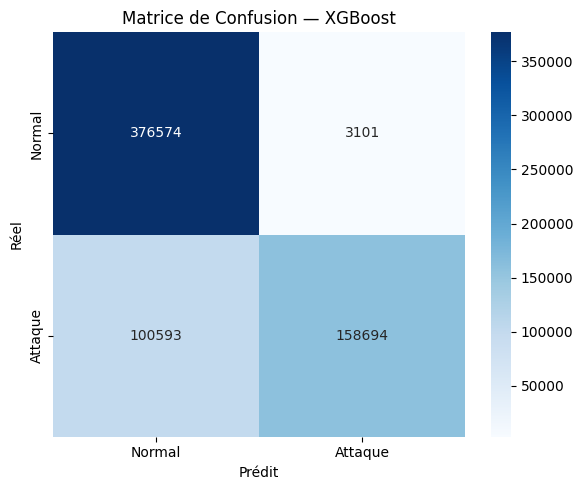

=== XGBoost ===
              precision    recall  f1-score   support

      Normal       0.79      0.99      0.88    379675
     Attaque       0.98      0.61      0.75    259287

    accuracy                           0.84    638962
   macro avg       0.89      0.80      0.82    638962
weighted avg       0.87      0.84      0.83    638962




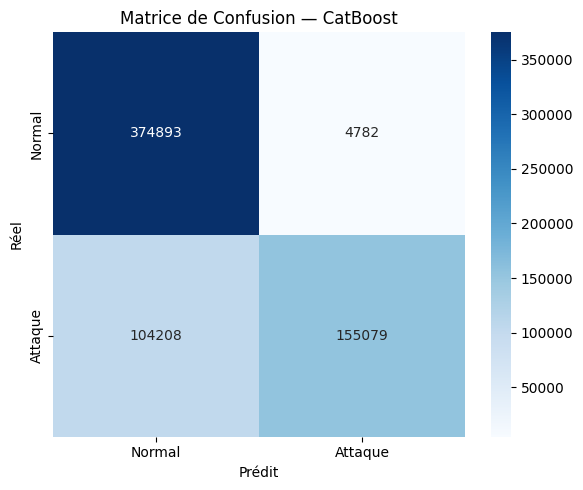

=== CatBoost ===
              precision    recall  f1-score   support

      Normal       0.78      0.99      0.87    379675
     Attaque       0.97      0.60      0.74    259287

    accuracy                           0.83    638962
   macro avg       0.88      0.79      0.81    638962
weighted avg       0.86      0.83      0.82    638962




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.metrics import confusion_matrix, classification_report


X_test = pd.read_csv('../data/processed/X_test.csv')
y_test_binary = pd.read_csv('../data/processed/y_test_binary.csv').squeeze()

model_names = {
    'Logistic Regression': 'logistic_regression_binary.pkl',
    'Decision Tree': 'decision_tree_binary.pkl',
    'AdaBoost': 'adaboost_binary.pkl',
    'Random Forest': 'random_forest_binary.pkl',
    'DNN': 'dnn_binary.pkl',
    'XGBoost': 'xgboost_binary.pkl',
    'CatBoost': 'catboost_binary.pkl'
}

os.makedirs('../figures', exist_ok=True)

for name, filename in model_names.items():
    with open(f'../models/{filename}', 'rb') as f:
        model = pickle.load(f)
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test_binary, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attaque'],
                yticklabels=['Normal', 'Attaque'])
    plt.title(f'Matrice de Confusion — {name}')
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.savefig(f'../figures/confusion_matrix_{name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    
    print(f'=== {name} ===')
    print(classification_report(y_test_binary, y_pred,
                                target_names=['Normal', 'Attaque']))
    print()
